# 🚀 AI for Beginners — ML Prerequisites Notebook
### Before Phase 2 · Allocate 2–3 focused days

Welcome! You've completed **Phase 1: Python Foundations** (Weeks 1–3).  
Before diving into **Phase 2: Intro to ML/DL** (Week 4 onwards), this notebook walks you through the five essential pillars you need to be comfortable with:

| # | Topic | What You'll Learn |
|---|-------|------------------|
| 1 | **NumPy** | Arrays, vectorised ops, broadcasting |
| 2 | **Pandas** | DataFrames, groupby, merging, cleaning |
| 3 | **Matplotlib / Seaborn** | Line, scatter, bar charts; heatmaps |
| 4 | **Scikit-learn** | Pipelines, preprocessing, model API |
| 5 | **Basic Statistics** | Mean, std dev, normal distribution, correlation |

> 💡 **Tip:** Work through each section in order. Run every code cell, read the explanations, and try the mini-exercises at the end of each section.

---


## 🔧 Environment Setup

Run the cell below once to install / confirm all required libraries.

In [5]:
# Install required libraries (skip if already installed)
# !pip install numpy pandas matplotlib seaborn scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")
print(f"  NumPy    {np.__version__}")
print(f"  Pandas   {pd.__version__}")
print(f"  Seaborn  {sns.__version__}")


✅ All libraries imported successfully!
  NumPy    2.4.2
  Pandas   3.0.1
  Seaborn  0.13.2


---
## 1️⃣ NumPy — Numerical Python

**Why NumPy?**  
Machine learning is fundamentally math on large arrays of numbers. NumPy gives you:
- A powerful **N-dimensional array** (`ndarray`) type
- **Vectorised operations** — apply math to a whole array at once (no Python loops!)
- **Broadcasting** — do math between arrays of different shapes

---
### 1.1 Creating Arrays


In [ ]:
l = [1,2,3]

In [7]:
# ----- 1.1  Creating Arrays -----

# From a Python list
a = np.array([1, 2, 3, 4, 5])
print("1D array:", a)
print("Shape:", a.shape, "  dtype:", a.dtype)

# 2D array (matrix)
matrix = np.array([[1, 2, 3],
                   [4, 5, 6],
                   [7, 8, 9]])
print("\n2D array (matrix):\n", matrix)
print("Shape:", matrix.shape)

# Utility constructors
print("\nnp.zeros(4):    ", np.zeros(4))
print("np.ones((2,3)):\n", np.ones((2, 3)))
print("np.arange(0,10,2):", np.arange(0, 10, 2))
print("np.linspace(0,1,5):", np.linspace(0, 1, 5))
print("np.random.randn(3,3):\n", np.random.randn(3, 3).round(3))


1D array: [1 2 3 4 5]
Shape: (5,)   dtype: int64

2D array (matrix):
 [[1 2 3]
 [4 5 6]
 [7 8 9]]
Shape: (3, 3)

np.zeros(4):     [0. 0. 0. 0.]
np.ones((2,3)):
 [[1. 1. 1.]
 [1. 1. 1.]]
np.arange(0,10,2): [0 2 4 6 8]
np.linspace(0,1,5): [0.   0.25 0.5  0.75 1.  ]
np.random.randn(3,3):
 [[0.226 1.224 0.43 ]
 [1.289 0.58  1.406]
 [2.044 1.031 0.207]]


 Why is NumPy so much faster?
 1. Contiguous Memory: NumPy arrays store data in one uninterrupted block of your computer's memory. Python lists store "pointers" scattered all across your memory, forcing your computer to look up locations constantly.No Type Checking: In a Python loop, Python must check the data type of every single element during every single iteration to make sure it can be added to 
 2. NumPy arrays strictly enforce one data type (e.g., integers), skipping this overhead entirely.

In [9]:
import time

# 1. Create a dataset of 10 million numbers
size = 10_000_000
python_list = list(range(size)) #[1,2,3,4,..., 1Cr]
numpy_array = np.arange(size)

print("⚡ Starting benchmark...")

# 2. Benchmark standard Python list comprehension (for loop)
start_time = time.time()
list_result = [x + 2 for x in python_list] # -> [3,4,5,6, ..., 1Cr+2]
loop_duration = time.time() - start_time
print(f"Standard Python Loop: {loop_duration:.4f} seconds")

# 3. Benchmark NumPy vectorized addition
start_time = time.time()
array_result = numpy_array + 2 # -> [3,4,5,6, ..., 1Cr+2]
numpy_duration = time.time() - start_time
print(f"NumPy Vectorization:  {numpy_duration:.4f} seconds")

# 4. Calculate the difference
speedup = loop_duration / numpy_duration
print(f"\n🚀 NumPy is {speedup:.1f}x FASTER than a standard loop!")


⚡ Starting benchmark...
Standard Python Loop: 0.3344 seconds
NumPy Vectorization:  0.0089 seconds

🚀 NumPy is 37.7x FASTER than a standard loop!


### 1.2 Vectorised Operations

Instead of writing a `for` loop, NumPy applies operations to the **entire array at once** — much faster and cleaner.


In [ ]:
# ----- 1.2  Vectorised Operations -----

scores = np.array([55, 70, 82, 91, 46, 63])

# Arithmetic — applied element-wise
print("Original scores:  ", scores)
print("Scores + 5 bonus: ", scores + 5)
print("Scores / 100:     ", scores / 100)
print("Scores ** 2:      ", scores ** 2)

# Comparison → boolean mask
passing = scores >= 60
print("\nPassing? (>=60): ", passing)
print("Passing scores:   ", scores[passing])   # boolean indexing

# Aggregate stats
print("\nMean:  ", scores.mean())
print("Max:   ", scores.max())
print("Argmax:", scores.argmax(), " ← index of highest score")


### 1.3 Broadcasting

Broadcasting lets NumPy **stretch** a smaller array to match a larger one so they can be combined — without copying data.

**Rule of thumb:** Two dimensions are compatible if they are *equal* or one of them is *1*.


In [ ]:
# ----- 1.3  Broadcasting -----

# Example 1 — subtract the mean of each column (common normalisation step)
data = np.array([[10, 200, 0.5],
                 [20, 150, 0.8],
                 [30, 180, 0.3]])

col_means = data.mean(axis=0)          # shape (3,)
print("Column means:", col_means)

centred = data - col_means             # (3,3) - (3,)  → broadcasts row-wise
print("\nCentred data:\n", centred.round(2))

# Example 2 — outer product via broadcasting
row = np.array([[1], [2], [3]])        # shape (3,1)
col = np.array([10, 20, 30])           # shape (3,)
product = row * col                    # (3,1) * (3,) → (3,3)
print("\nOuter product via broadcasting:\n", product)


### 1.4 Indexing & Slicing


In [ ]:
# ----- 1.4  Indexing & Slicing -----

m = np.arange(1, 26).reshape(5, 5)
print("5×5 matrix:\n", m)

print("\nRow 0:            ", m[0])
print("Column 2:         ", m[:, 2])
print("Sub-matrix [1:3, 1:3]:\n", m[1:3, 1:3])
print("Every 2nd row, last 2 cols:\n", m[::2, -2:])

# Fancy indexing
rows = np.array([0, 2, 4])
print("\nRows 0, 2, 4:\n", m[rows])


### 🏋️ NumPy Mini-Exercise

Try these on your own:

1. Create a 1D array of 20 evenly-spaced values between 0 and π.
2. Compute the sine of each value.
3. Find the index of the maximum value.
4. Reshape the sine values into a 4×5 matrix.


In [ ]:
# Your solution here
# 1.
# 2.
# 3.
# 4.


---
## 2️⃣ Pandas — Data Manipulation

**Why Pandas?**  
Real-world ML data lives in tables (CSV, Excel, SQL). Pandas gives you the **DataFrame** — a labelled 2D table you can slice, filter, group, merge, and clean with ease.

---
### 2.1 Creating DataFrames


In [11]:
# ----- 2.1  Creating DataFrames -----

# From a dict
students = pd.DataFrame({
    'name':    ['Alice', 'Bob', 'Carol', 'Dave', 'Eve'],
    'score':   [88, 73, 95, 61, 82],
    'grade':   ['B', 'C', 'A', 'D', 'B'],
    'passed':  [True, True, True, False, True],
    'hours':   [12, 8, 15, 5, 10]
})
print(students)
print("\nShape:", students.shape)
print("Dtypes:\n", students.dtypes)


    name  score grade  passed  hours
0  Alice     88     B    True     12
1    Bob     73     C    True      8
2  Carol     95     A    True     15
3   Dave     61     D   False      5
4    Eve     82     B    True     10

Shape: (5, 5)
Dtypes:
 name        str
score     int64
grade       str
passed     bool
hours     int64
dtype: object


### 2.2 Selection & Filtering


In [12]:
# ----- 2.2  Selection & Filtering -----

# Single column → Series
print("Scores:", students['score'].values)

# Multiple columns
print("\nName + Score:")
print(students[['name', 'score']])

# Boolean filter
print("\nStudents who passed:")
print(students[students['passed'] == True])

print("\nHigh scorers (>=80):")
print(students[students['score'] >= 80][['name', 'score', 'grade']])

# .loc  — label-based
print("\nRow at index 2:", students.loc[2, 'name'], "-", students.loc[2, 'score'])

# .iloc — position-based
print("First 3 rows, first 3 cols:\n", students.iloc[:3, :3])


Scores: [88 73 95 61 82]

Name + Score:
    name  score
0  Alice     88
1    Bob     73
2  Carol     95
3   Dave     61
4    Eve     82

Students who passed:
    name  score grade  passed  hours
0  Alice     88     B    True     12
1    Bob     73     C    True      8
2  Carol     95     A    True     15
4    Eve     82     B    True     10

High scorers (>=80):
    name  score grade
0  Alice     88     B
2  Carol     95     A
4    Eve     82     B

Row at index 2: Carol - 95
First 3 rows, first 3 cols:
     name  score grade
0  Alice     88     B
1    Bob     73     C
2  Carol     95     A


### 2.3 GroupBy — Split → Apply → Combine

`groupby()` is one of Pandas' most powerful tools. It mirrors SQL `GROUP BY`.


In [ ]:
# ----- 2.3  GroupBy -----

# Average score per grade
print("Average score by grade:")
print(students.groupby('grade')['score'].mean().sort_values(ascending=False))

# Multiple aggregations at once
print("\nStats per grade:")
print(students.groupby('grade').agg(
    avg_score=('score', 'mean'),
    total_students=('name', 'count'),
    avg_hours=('hours', 'mean')
).round(1))


### 2.4 Merging DataFrames

`merge()` joins two DataFrames — like SQL JOIN.


In [ ]:
# ----- 2.4  Merging -----

# Extra info table
extra = pd.DataFrame({
    'name': ['Alice', 'Bob', 'Carol', 'Dave', 'Eve'],
    'city': ['New York', 'London', 'Paris', 'Tokyo', 'Sydney'],
    'age':  [22, 25, 21, 23, 24]
})

# Inner merge on 'name'
merged = students.merge(extra, on='name', how='inner')
print("Merged DataFrame:")
print(merged[['name', 'score', 'grade', 'city', 'age']])


### 2.5 Handling Missing Data

Missing values (`NaN`) are extremely common in real datasets.


In [ ]:
# ----- 2.5  Missing Data -----

# Simulate a messy dataset
messy = pd.DataFrame({
    'feature_a': [1.0, 2.0, np.nan, 4.0, 5.0, np.nan],
    'feature_b': [10,  np.nan, 30, 40, np.nan, 60],
    'label':     ['cat', 'dog', 'cat', np.nan, 'dog', 'cat']
})

print("Raw data with NaNs:")
print(messy)

print("\nMissing value counts:")
print(messy.isnull().sum())

# Fill numeric NaN with column mean
messy['feature_a'].fillna(messy['feature_a'].mean(), inplace=True)
messy['feature_b'].fillna(messy['feature_b'].median(), inplace=True)

# Fill categorical NaN with mode
messy['label'].fillna(messy['label'].mode()[0], inplace=True)

print("\nAfter filling NaNs:")
print(messy)
print("Remaining NaNs:", messy.isnull().sum().sum())


### 2.6 Reading & Exploring Real Data


In [ ]:
# ----- 2.6  Exploring a Built-in Dataset -----

# Load the classic Titanic-style dataset from seaborn
titanic = sns.load_dataset('titanic')

print("Shape:", titanic.shape)
print("\nFirst 5 rows:")
print(titanic.head())

print("\n--- .info() ---")
titanic.info()

print("\n--- .describe() ---")
print(titanic.describe().round(2))

print("\nMissing values:")
print(titanic.isnull().sum()[titanic.isnull().sum() > 0])


### 🏋️ Pandas Mini-Exercise

Using the `titanic` DataFrame loaded above:

1. Find the survival rate (`survived`) for each passenger class (`pclass`).
2. Find the average age per sex.
3. How many passengers embarked from each port (`embark_town`)?


In [ ]:
# Your solution here
# 1.
# 2.
# 3.


---
## 3️⃣ Matplotlib & Seaborn — Data Visualisation

**Why visualise?**  
A picture is worth 1000 rows. Before training any model, you must *understand* your data — spot distributions, outliers, correlations, and class imbalances.

- **Matplotlib** — low-level, full control
- **Seaborn** — high-level, beautiful statistical plots built on Matplotlib

---
### 3.1 Line Chart (Matplotlib)


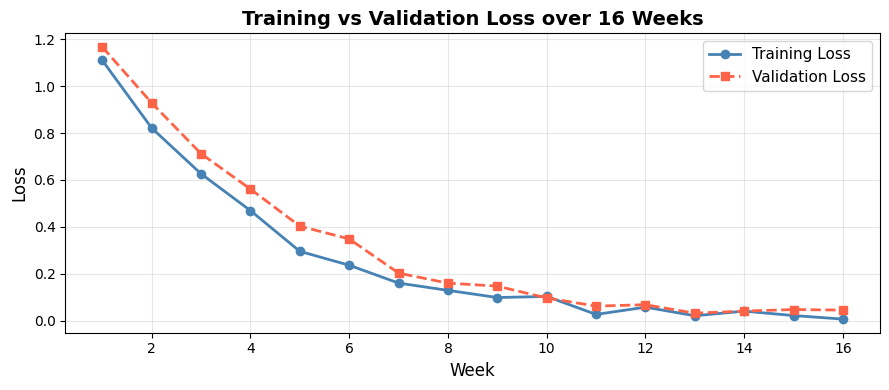

✅ Line chart — good for tracking change over time


In [13]:
# ----- 3.1  Line Chart -----

weeks = np.arange(1, 17)
train_loss = 1.5 * np.exp(-0.3 * weeks) + np.random.normal(0, 0.02, 16)
val_loss   = 1.5 * np.exp(-0.25 * weeks) + np.random.normal(0, 0.03, 16)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(weeks, train_loss, marker='o', label='Training Loss',   color='steelblue', linewidth=2)
ax.plot(weeks, val_loss,   marker='s', label='Validation Loss', color='tomato',    linewidth=2, linestyle='--')
ax.set_xlabel('Week', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Training vs Validation Loss over 16 Weeks', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("✅ Line chart — good for tracking change over time")


### 3.2 Scatter Plot


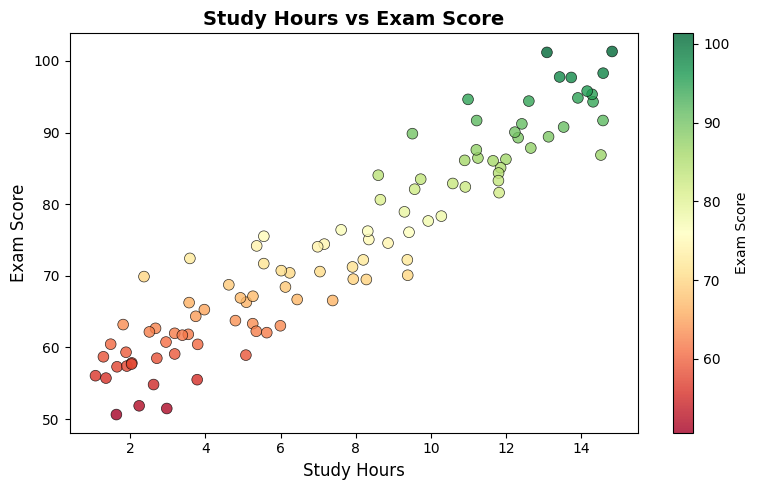

✅ Scatter — great for spotting relationships between two numeric variables


In [15]:
# ----- 3.2  Scatter Plot -----

np.random.seed(42)
study_hours = np.random.uniform(1, 15, 100)
exam_score  = 50 + 3.2 * study_hours + np.random.normal(0, 5, 100)

fig, ax = plt.subplots(figsize=(8, 5))
scatter = ax.scatter(study_hours, exam_score, c=exam_score, cmap='RdYlGn',
                     alpha=0.8, edgecolors='k', linewidths=0.5, s=60)
plt.colorbar(scatter, ax=ax, label='Exam Score')
ax.set_xlabel('Study Hours', fontsize=12)
ax.set_ylabel('Exam Score', fontsize=12)
ax.set_title('Study Hours vs Exam Score', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ Scatter — great for spotting relationships between two numeric variables")


### 3.3 Bar Chart


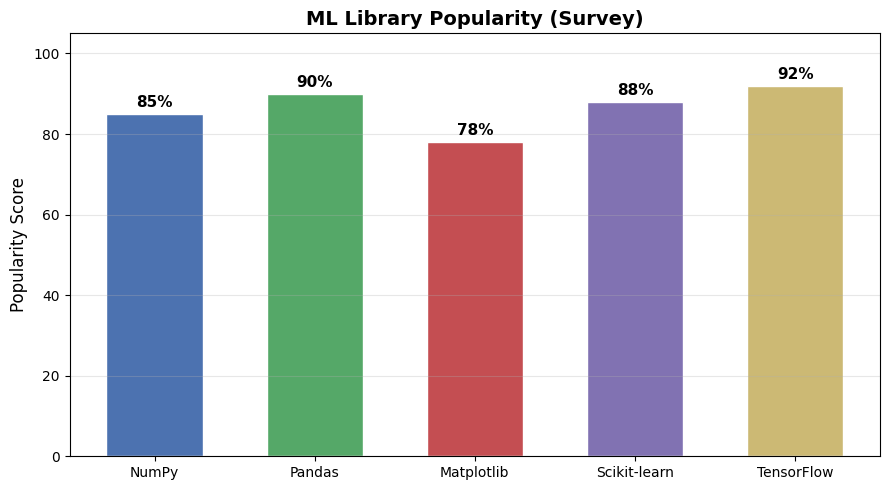

✅ Bar chart — compare categories


In [16]:
# ----- 3.3  Bar Chart -----

labels = ['NumPy', 'Pandas', 'Matplotlib', 'Scikit-learn', 'TensorFlow']
popularity = [85, 90, 78, 88, 92]
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(labels, popularity, color=colors, edgecolor='white', width=0.6)
ax.bar_label(bars, fmt='%d%%', padding=3, fontsize=11, fontweight='bold')
ax.set_ylim(0, 105)
ax.set_ylabel('Popularity Score', fontsize=12)
ax.set_title('ML Library Popularity (Survey)', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
print("✅ Bar chart — compare categories")


### 3.4 Distribution Plot (Seaborn)


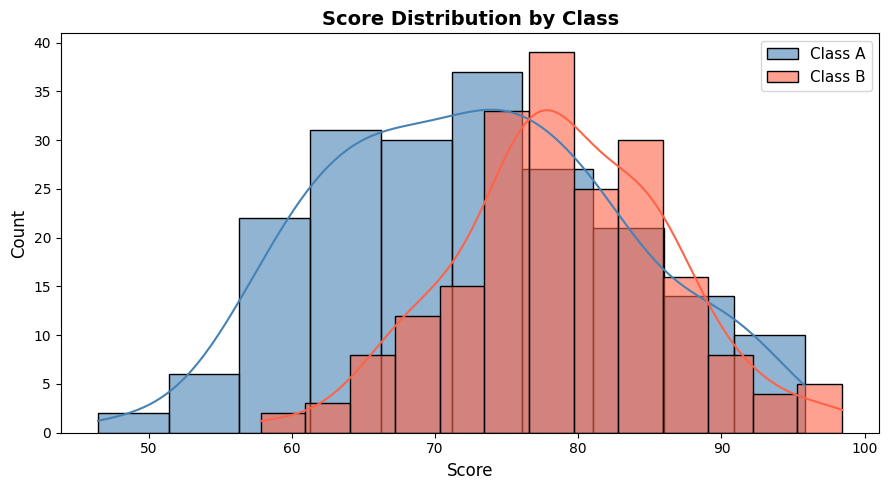

✅ Distribution plot — understand how values spread


In [17]:
# ----- 3.4  Distribution Plot -----

np.random.seed(0)
scores_class_a = np.random.normal(72, 10, 200)
scores_class_b = np.random.normal(80, 8, 200)

fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(scores_class_a, kde=True, color='steelblue', label='Class A', alpha=0.6, ax=ax)
sns.histplot(scores_class_b, kde=True, color='tomato',    label='Class B', alpha=0.6, ax=ax)
ax.set_xlabel('Score', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Score Distribution by Class', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()
print("✅ Distribution plot — understand how values spread")


### 3.5 Heatmap — Correlation Matrix

One of the most important plots before ML: which features are correlated?


In [ ]:
# ----- 3.5  Heatmap -----

# Use numeric columns of the Titanic dataset
numeric_titanic = titanic[['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']].dropna()
corr = numeric_titanic.corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Feature Correlation Heatmap — Titanic', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ Values close to +1 = strong positive correlation, -1 = strong negative")


### 3.6 Seaborn Pair Plot & Box Plot


In [ ]:
# ----- 3.6a  Box Plot -----

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Box plot — fare by class
sns.boxplot(data=titanic, x='pclass', y='fare', palette='Set2', ax=axes[0])
axes[0].set_title('Fare Distribution by Passenger Class', fontweight='bold')
axes[0].set_xlabel('Passenger Class')
axes[0].set_ylabel('Fare (£)')

# Count plot — survival by sex
sns.countplot(data=titanic, x='sex', hue='survived', palette=['tomato', 'steelblue'], ax=axes[1])
axes[1].set_title('Survival Count by Sex', fontweight='bold')
axes[1].set_xlabel('Sex')
axes[1].legend(title='Survived', labels=['No', 'Yes'])

plt.tight_layout()
plt.show()


### 🏋️ Visualisation Mini-Exercise

1. Plot a histogram of the `age` column from the Titanic dataset.
2. Create a bar chart showing average fare per passenger class.
3. Make a scatter plot of `age` vs `fare`, coloured by `survived`.


In [ ]:
# Your solution here
# 1.
# 2.
# 3.


---
## 4️⃣ Scikit-learn — The ML Swiss Army Knife

**Why Scikit-learn?**  
Scikit-learn gives you a **unified API** for virtually every classical ML task:

| Stage | Tools |
|-------|-------|
| Preprocessing | `StandardScaler`, `LabelEncoder`, `OneHotEncoder`, `SimpleImputer` |
| Splitting | `train_test_split` |
| Models | `LinearRegression`, `LogisticRegression`, `RandomForestClassifier`, … |
| Pipelines | Chain preprocessing + model in one object |
| Evaluation | `accuracy_score`, `classification_report`, `mean_squared_error`, … |

---
### 4.1 The Standard Workflow


In [ ]:
# ----- 4.1  Scikit-learn Standard Workflow -----
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# Step 1 — Load data
iris = load_iris()
X, y = iris.data, iris.target
feature_names = iris.feature_names
class_names   = iris.target_names

print("Dataset shape:", X.shape)
print("Classes:", class_names)
print("Features:", feature_names)


In [ ]:
# Step 2 — Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}")
print("Class distribution in train:", np.bincount(y_train))
print("Class distribution in test: ", np.bincount(y_test))


In [ ]:
# Step 3 — Preprocessing: StandardScaler
# Scales each feature to zero mean, unit variance
# IMPORTANT: fit ONLY on training data to avoid data leakage!

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform
X_test_scaled  = scaler.transform(X_test)         # transform only!

print("Before scaling — mean of first feature:", X_train[:, 0].mean().round(4))
print("After scaling  — mean of first feature:", X_train_scaled[:, 0].mean().round(4))
print("After scaling  — std  of first feature:", X_train_scaled[:, 0].std().round(4))


In [ ]:
# Step 4 — Train a model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
print("Model trained ✅")

# Step 5 — Evaluate
y_pred = knn.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)
print(f"\nTest Accuracy: {acc:.2%}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))


### 4.2 Preprocessing — Key Transformers


In [ ]:
# ----- 4.2  Preprocessing Tools -----
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer

# ── Label Encoding (ordinal / binary categories)
le = LabelEncoder()
raw_labels = ['cat', 'dog', 'cat', 'bird', 'dog']
encoded = le.fit_transform(raw_labels)
print("Label Encoding:")
print("  Classes:", le.classes_)
print("  Encoded:", encoded)
print("  Decoded:", le.inverse_transform(encoded))

# ── SimpleImputer (fill missing values)
print("\nSimpleImputer:")
X_missing = np.array([[1., 2.], [np.nan, 3.], [7., np.nan]])
imputer = SimpleImputer(strategy='mean')
print("  Input:\n", X_missing)
print("  Imputed:\n", imputer.fit_transform(X_missing))


### 4.3 Pipelines — Chain Steps Together

A `Pipeline` bundles preprocessing + model into **one object**. Benefits:
- No data leakage
- Easy `fit`/`predict` calls
- Cross-validation works correctly


In [ ]:
# ----- 4.3  Pipeline -----
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  SVC(kernel='rbf', C=1.0, random_state=42))
])

# fit / predict work exactly like a single model
pipe.fit(X_train, y_train)
y_pred_pipe = pipe.predict(X_test)
print("Pipeline accuracy:", accuracy_score(y_test, y_pred_pipe))

# Cross-validation — 5-fold
cv_scores = cross_val_score(pipe, X, y, cv=5, scoring='accuracy')
print(f"5-fold CV scores: {cv_scores.round(3)}")
print(f"Mean CV accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")


### 4.4 The Model API — fit, predict, score

Every Scikit-learn estimator follows the same three-method API:

| Method | Purpose |
|--------|---------|
| `model.fit(X_train, y_train)` | Train the model |
| `model.predict(X_test)` | Make predictions |
| `model.score(X_test, y_test)` | Evaluate (accuracy for classifiers, R² for regressors) |


In [ ]:
# ----- 4.4  Regression Example -----
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Synthetic house price data
np.random.seed(7)
size   = np.random.uniform(500, 3500, 200)
rooms  = np.random.randint(1, 7, 200).astype(float)
price  = 50000 + 120 * size + 25000 * rooms + np.random.normal(0, 20000, 200)

X_house = np.column_stack([size, rooms])
y_house = price

X_tr, X_te, y_tr, y_te = train_test_split(X_house, y_house, test_size=0.2, random_state=1)

lr = LinearRegression()
lr.fit(X_tr, y_tr)
y_hat = lr.predict(X_te)

print("Linear Regression — House Price")
print(f"  Intercept: ${lr.intercept_:,.0f}")
print(f"  Coefficients: size=${lr.coef_[0]:.1f}/sqft, rooms=${lr.coef_[1]:,.0f}/room")
print(f"  R² score: {r2_score(y_te, y_hat):.4f}")
print(f"  RMSE:     ${np.sqrt(mean_squared_error(y_te, y_hat)):,.0f}")


### 🏋️ Scikit-learn Mini-Exercise

Using the Iris dataset:

1. Train a `RandomForestClassifier` (from `sklearn.ensemble`) with default parameters.
2. Evaluate it with `classification_report`.
3. Wrap it in a `Pipeline` with `StandardScaler` and evaluate again — does scaling matter for Random Forest?


In [ ]:
# Your solution here
from sklearn.ensemble import RandomForestClassifier
# 1.
# 2.
# 3.


---
## 5️⃣ Basic Statistics

**Why statistics?**  
ML *is* applied statistics. Every algorithm makes statistical assumptions. Understanding these concepts helps you choose the right model, interpret results, and debug when things go wrong.

---
### 5.1 Measures of Central Tendency


In [ ]:
# ----- 5.1  Central Tendency -----

grades = np.array([55, 62, 70, 72, 73, 75, 75, 78, 80, 82, 85, 88, 90, 92, 98])

mean   = np.mean(grades)
median = np.median(grades)

from scipy import stats
mode_result = stats.mode(grades, keepdims=True)
mode_val = mode_result.mode[0]

print("Grades:", grades)
print(f"\nMean   : {mean:.1f}  — average of all values")
print(f"Median : {median:.1f}  — middle value; robust to outliers")
print(f"Mode   : {mode_val}    — most frequent value")

# Effect of an outlier
grades_with_outlier = np.append(grades, 5)   # a student got 5/100
print("\n-- With an outlier (5) added --")
print(f"Mean   : {grades_with_outlier.mean():.1f}  ← pulled down")
print(f"Median : {np.median(grades_with_outlier):.1f}  ← barely moved")


### 5.2 Measures of Spread


In [ ]:
# ----- 5.2  Spread -----

data_a = np.array([48, 50, 51, 50, 49, 50, 52, 48])    # tight cluster
data_b = np.array([10, 30, 50, 70, 90, 20, 80, 60])     # spread out

for label, d in [('A (tight)', data_a), ('B (spread)', data_b)]:
    print(f"Dataset {label}")
    print(f"  Mean:     {d.mean():.1f}")
    print(f"  Variance: {d.var():.1f}   ← avg squared deviation from mean")
    print(f"  Std Dev:  {d.std():.1f}   ← square root of variance (same units as data)")
    q1, q3 = np.percentile(d, [25, 75])
    print(f"  IQR:      {q3-q1:.1f}   ← Q3−Q1 (robust to outliers)")
    print()


### 5.3 Normal Distribution

The normal (Gaussian) distribution is the backbone of statistics and many ML algorithms.

Key property: **68-95-99.7 rule**
- 68% of data falls within ±1 standard deviation of the mean
- 95% within ±2 std devs
- 99.7% within ±3 std devs


In [ ]:
# ----- 5.3  Normal Distribution -----

np.random.seed(42)
μ, σ = 70, 10          # mean=70, std=10
sample = np.random.normal(μ, σ, 1000)

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(sample, kde=True, color='steelblue', alpha=0.6, stat='density', ax=ax)

# Mark ±1, ±2, ±3 sigma
colors = ['gold', 'orange', 'tomato']
for i, (n, c) in enumerate(zip([1, 2, 3], colors), 1):
    ax.axvline(μ + n*σ, color=c, linestyle='--', linewidth=1.5, label=f'+{n}σ')
    ax.axvline(μ - n*σ, color=c, linestyle='--', linewidth=1.5)

ax.axvline(μ, color='navy', linestyle='-', linewidth=2, label=f'μ={μ}')

# Shade ±1σ region
x_fill = np.linspace(μ-σ, μ+σ, 300)
from scipy.stats import norm
ax.fill_between(x_fill, norm.pdf(x_fill, μ, σ), alpha=0.2, color='steelblue', label='±1σ ≈ 68%')

ax.set_title('Normal Distribution — 68-95-99.7 Rule', fontsize=14, fontweight='bold')
ax.set_xlabel('Score', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

within_1σ = ((sample >= μ-σ) & (sample <= μ+σ)).mean()
within_2σ = ((sample >= μ-2*σ) & (sample <= μ+2*σ)).mean()
print(f"Sample within ±1σ: {within_1σ:.1%}  (theory: 68.3%)")
print(f"Sample within ±2σ: {within_2σ:.1%}  (theory: 95.4%)")


### 5.4 Correlation

Correlation measures the **linear relationship** between two variables.
- **+1** = perfect positive correlation
- **0** = no linear relationship
- **-1** = perfect negative correlation


In [ ]:
# ----- 5.4  Correlation -----

np.random.seed(10)
n = 150

# Four types of relationship
x = np.random.uniform(-3, 3, n)
y_pos  = 2*x + np.random.normal(0, 0.5, n)         # positive
y_neg  = -1.5*x + np.random.normal(0, 0.5, n)      # negative
y_none = np.random.normal(0, 1, n)                   # none
y_curv = x**2 + np.random.normal(0, 0.5, n)         # non-linear (correlation misleads!)

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
pairs = [
    (x, y_pos,  "Positive"),
    (x, y_neg,  "Negative"),
    (x, y_none, "No linear rel."),
    (x, y_curv, "Non-linear")
]
for ax, (xi, yi, title) in zip(axes, pairs):
    r = np.corrcoef(xi, yi)[0, 1]
    ax.scatter(xi, yi, alpha=0.5, s=15, color='steelblue')
    ax.set_xlabel('x'); ax.set_ylabel('y')
plt.suptitle('Pearson Correlation — Four Scenarios', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("⚠️  Correlation only captures LINEAR relationships!")
print("   The non-linear plot (r≈0) has a very clear pattern — correlation misses it.")


### 5.5 Putting It All Together — Exploratory Data Analysis (EDA)

Before training any model, always run a quick EDA:


In [ ]:
# ----- 5.5  Full EDA on Titanic -----

df = titanic[['survived', 'pclass', 'sex', 'age', 'fare', 'sibsp', 'parch']].copy()
df['age'].fillna(df['age'].median(), inplace=True)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# 1 — Age distribution
sns.histplot(df['age'], kde=True, color='steelblue', ax=axes[0, 0])
axes[0, 0].set_title('Age Distribution', fontweight='bold')
axes[0, 0].axvline(df['age'].mean(),   color='tomato',    linestyle='--', label=f'Mean {df["age"].mean():.1f}')
axes[0, 0].axvline(df['age'].median(), color='darkgreen', linestyle='--', label=f'Median {df["age"].median():.1f}')
axes[0, 0].legend()

# 2 — Fare by class
sns.boxplot(data=df, x='pclass', y='fare', palette='Set2', ax=axes[0, 1])
axes[0, 1].set_title('Fare by Passenger Class', fontweight='bold')

# 3 — Survival by class
sns.barplot(data=df, x='pclass', y='survived', palette='Set1', ax=axes[0, 2])
axes[0, 2].set_title('Survival Rate by Class', fontweight='bold')
axes[0, 2].set_ylabel('Survival Rate')

# 4 — Survival by sex
sns.barplot(data=df, x='sex', y='survived', palette='Set2', ax=axes[1, 0])
axes[1, 0].set_title('Survival Rate by Sex', fontweight='bold')

# 5 — Correlation heatmap
corr = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, ax=axes[1, 1])
axes[1, 1].set_title('Correlation Heatmap', fontweight='bold')

# 6 — Age vs Fare scatter
sc = axes[1, 2].scatter(df['age'], df['fare'], c=df['survived'],
                         cmap='RdYlGn', alpha=0.5, s=20)
axes[1, 2].set_title('Age vs Fare (green=survived)', fontweight='bold')
axes[1, 2].set_xlabel('Age'); axes[1, 2].set_ylabel('Fare')

plt.suptitle('Titanic EDA Dashboard', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Summary statistics
print("\n📊 Key Statistics — Titanic Numeric Features")
print(df.describe().round(2))


### 🏋️ Statistics Mini-Exercise

1. Compute the mean, median, and standard deviation of the `fare` column in the Titanic dataset.
2. Is `fare` normally distributed? Plot its histogram and check.
3. Compute the correlation between `fare` and `survived`. What does this tell you?


In [ ]:
# Your solution here
# 1.
# 2.
# 3.


---
## ✅ Recap & Readiness Checklist

Before moving to Phase 2, make sure you can answer **yes** to each of these:

### NumPy
- [ ] I can create arrays with `np.array`, `np.zeros`, `np.arange`, `np.linspace`
- [ ] I understand element-wise vs. matrix operations
- [ ] I can use boolean indexing to filter arrays
- [ ] I understand what broadcasting means

### Pandas
- [ ] I can create a `DataFrame` from a dict or CSV
- [ ] I can filter rows with boolean conditions
- [ ] I can use `groupby().agg()` to summarise data
- [ ] I can handle missing values with `fillna` / `dropna`
- [ ] I can merge two DataFrames with `merge()`

### Matplotlib / Seaborn
- [ ] I can create line, scatter, bar, and histogram plots
- [ ] I can add titles, axis labels, and legends
- [ ] I can plot a heatmap from a correlation matrix
- [ ] I can create a multi-panel figure with `plt.subplots`

### Scikit-learn
- [ ] I understand the `fit → predict → score` API
- [ ] I can split data with `train_test_split`
- [ ] I can scale features with `StandardScaler`
- [ ] I can build a `Pipeline` with preprocessing + model
- [ ] I know the difference between classification and regression metrics

### Statistics
- [ ] I can explain mean, median, mode, variance, std dev
- [ ] I understand the 68-95-99.7 rule of the normal distribution
- [ ] I can compute and interpret Pearson correlation
- [ ] I know why correlation ≠ causation

---
## 📚 Recommended Resources

| Resource | Link | What to do |
|----------|------|------------|
| **Kaggle Learn — Python** | https://www.kaggle.com/learn/python | Quick revision |
| **Kaggle Learn — Pandas** | https://www.kaggle.com/learn/pandas | Complete all exercises |
| **Kaggle Learn — Data Visualisation** | https://www.kaggle.com/learn/data-visualization | Complete all exercises |
| **Kaggle Learn — Intro to ML** | https://www.kaggle.com/learn/intro-to-machine-learning | Preview of Phase 2 |
| **NumPy Quickstart** | https://numpy.org/doc/stable/user/quickstart.html | Reference |
| **Scikit-learn User Guide** | https://scikit-learn.org/stable/user_guide.html | Reference |

---

> 🎉 **You're ready for Phase 2 — Intro to ML/DL!**  
> Week 4 starts with supervised & unsupervised learning, the train/test split, and your first real datasets (Iris, Titanic).  
> See you there!
